# Data Exploration and Parameter Exploration for Population Event Detection and Analysis

## **Importing necessary packages**

In [3]:
import numpy as np
import matplotlib.pyplot as plt  
import os, requests
import spkit as sp
import glob
from scipy import signal as sps
import h5py
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
from scipy.ndimage import label
import pandas as pd

## **Importing Data/ General Preprocessing Functions**

In [39]:
file_name = 'data/Armaan_Testing.h5'

In [ ]:
#Replace name of file for analysis here
with h5py.File(file_name, "r") as f:
    dset = f["Data/Recording_0/AnalogStream/Stream_0/ChannelData"]
    n_channels, n_samples = dset.shape
    
    # Decimate one channel at a time to avoid loading everything at once
    test_decimated = sps.decimate(dset[0, :], 25)
    n_samples_dec = len(test_decimated)
    
    X = np.empty((n_channels, n_samples_dec), dtype=np.float32)
    
    for ch in range(n_channels):
        X[ch] = sps.decimate(dset[ch, :], 25)

In [3]:
SIGNAL_PATH = "Data/Recording_0/AnalogStream/Stream_0/ChannelData"
INFO_PATH   = "Data/Recording_0/AnalogStream/Stream_0/InfoChannel"

In [ ]:
with h5py.File(file_name, "r") as f:
  data = f[SIGNAL_PATH]
  info = f[INFO_PATH][:]
  field_names = list(info.dtype.fields.keys()) #How is one supposed to figure this out
  print(type(info[0]["Label"]))

<class 'bytes'>


In [20]:
np.savetxt("decimated_data.txt", X)

In [21]:
X.shape[1]

1199900

In [4]:
X = np.loadtxt("decimated_data.txt") #Runs in 3 min

In [3]:
X.shape #should be like 60, 1999000

(60, 1199900)

In [30]:
with h5py.File(file_name, "r") as f:
    info = f["Data/Recording_0/AnalogStream/Stream_0/InfoChannel"][:]
    print(info.dtype)
    for i, ch in enumerate(info[:5]):
        print(f"Channel {i}: {ch}")

[('ChannelID', '<i4'), ('RowIndex', '<i4'), ('GroupID', '<i4'), ('ElectrodeGroup', '<i4'), ('Label', 'O'), ('RawDataType', 'O'), ('Unit', 'O'), ('Exponent', '<i4'), ('ADZero', '<i4'), ('Tick', '<i8'), ('ConversionFactor', '<i8'), ('ADCBits', '<i4'), ('HighPassFilterType', 'O'), ('HighPassFilterCutOffFrequency', 'O'), ('HighPassFilterOrder', '<i4'), ('LowPassFilterType', 'O'), ('LowPassFilterCutOffFrequency', 'O'), ('LowPassFilterOrder', '<i4')]
Channel 0: (0, 0, 0, 0, b'47', b'Int', b'V', -12, 0, 40, 113636, 16, b'', b'-1', -1, b'', b'-1', -1)
Channel 1: (1, 1, 0, 0, b'48', b'Int', b'V', -12, 0, 40, 113636, 16, b'', b'-1', -1, b'', b'-1', -1)
Channel 2: (2, 2, 0, 0, b'46', b'Int', b'V', -12, 0, 40, 113636, 16, b'', b'-1', -1, b'', b'-1', -1)
Channel 3: (3, 3, 0, 0, b'45', b'Int', b'V', -12, 0, 40, 113636, 16, b'', b'-1', -1, b'', b'-1', -1)
Channel 4: (4, 4, 0, 0, b'38', b'Int', b'V', -12, 0, 40, 113636, 16, b'', b'-1', -1, b'', b'-1', -1)


In [7]:
X.shape[0], X.shape[1]

(60, 1199900)

In [6]:
def exclude_bad_channels(X, multiplier=1.5):
  
  rms_list = np.sqrt(np.mean(X**2, axis=1))  # vectorised, shape (n_channels,)
  
  mean_rms = np.mean(rms_list)
  
  good_indices = np.where(rms_list < mean_rms * multiplier)[0].tolist()

  bad_indices = np.where(rms_list >= mean_rms * multiplier)[0].tolist()
    
  return good_indices, bad_indices


In [5]:
BAND = (0.1, 200)
FS = 1000
B, A = sps.butter(3, list(BAND), btype="bandpass", fs=FS)

def bandpass_filter(data):
    return sps.filtfilt(B, A, data)

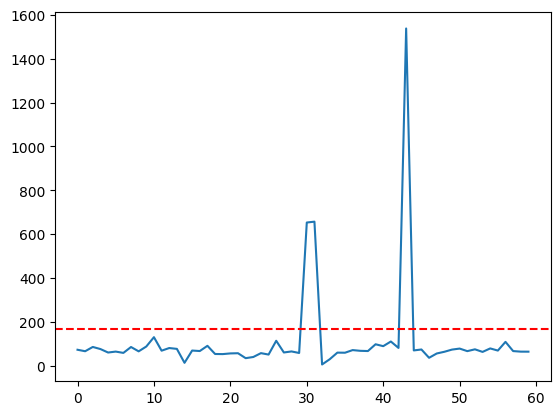

In [8]:
rms_list = np.sqrt(np.mean(X**2, axis=1))
plt.plot(rms_list) #See what a reasonable cutoff for shitty channels is
plt.axhline(np.mean(rms_list) * 1.5, color='red', linestyle='--') #Example cutoff line

In [9]:
def artifact_removal(X: np.ndarray) -> np.ndarray:
  """
  After removing bad channels, now we can try to remove time locked artifacts using the common median reference method
  """
  med = np.median(X, axis=0)
  cmr = X - med
  return cmr

In [4]:
import numpy as np

def parse_mcs_labels(info):
    """
    Parse MCS electrode labels (e.g. b'47' -> row 4, col 7)
    Returns sorted indices, labels, and grid positions
    """
    labels = []
    positions = []

    for ch in info:
        label = ch['Label'].decode('utf-8').strip()
        labels.append(label)
        
        if len(label) == 2 and label.isdigit():
            col = int(label[0])
            row = int(label[1])
        else:
            # Handle any non-standard labels gracefully
            print(f"Unexpected label format: {label}")
            row, col = -1, -1
        
        positions.append((row, col))

    positions = np.array(positions)  # shape (n_channels, 2)

    # Sort by row first, then column
    sorted_indices = np.lexsort((positions[:, 1], positions[:, 0]))

    sorted_labels = [labels[i] for i in sorted_indices]
    sorted_positions = positions[sorted_indices]

    print("First 5 channels after reordering:")
    for i in range(5):
        idx = sorted_indices[i]
        print(f"  Storage index {idx} -> label {sorted_labels[i]} "
              f"(row {sorted_positions[i,0]}, col {sorted_positions[i,1]})")

    return sorted_indices, sorted_labels, sorted_positions


with h5py.File(file_name, "r") as f:
    info = f["Data/Recording_0/AnalogStream/Stream_0/InfoChannel"][:]

sorted_indices, sorted_labels, sorted_positions = parse_mcs_labels(info)



First 5 channels after reordering:
  Storage index 23 -> label 21 (row 1, col 2)
  Storage index 25 -> label 31 (row 1, col 3)
  Storage index 28 -> label 41 (row 1, col 4)
  Storage index 31 -> label 51 (row 1, col 5)
  Storage index 34 -> label 61 (row 1, col 6)


In [5]:
# Reorder your data array
X_sorted = X[sorted_indices, :]

In [46]:
#Validating CMR
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from itertools import combinations

def validate_cmr(raw, cmr, fs, electrode_positions):
    """
    raw:                (n_channels, n_samples) - before CMR
    cmr:                (n_channels, n_samples) - after CMR
    fs:                 sampling frequency (Hz)
    electrode_positions: (n_channels, 2) - x/y coords in µm
    """
    n_ch = raw.shape[0]
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    # --- 1. The median trace that was subtracted ---
    median_trace = np.median(raw, axis=0)
    t = np.arange(raw.shape[1]) / fs
    axes[0, 0].plot(t, median_trace, color='steelblue', linewidth=0.6)
    axes[0, 0].set_title('Common-mode trace (median subtracted)')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Voltage (µV)')

    # --- 2. PSD before vs. after (mean across channels) ---
    freqs, psd_raw = welch(raw, fs=fs, nperseg=1024, axis=1)
    freqs, psd_cmr = welch(cmr, fs=fs, nperseg=1024, axis=1)
    axes[0, 1].semilogy(freqs, psd_raw.mean(axis=0),
                        label='Before CMR', alpha=0.8)
    axes[0, 1].semilogy(freqs, psd_cmr.mean(axis=0),
                        label='After CMR', alpha=0.8)
    axes[0, 1].set_title('Mean PSD across channels')
    axes[0, 1].set_xlabel('Frequency (Hz)')
    axes[0, 1].set_ylabel('Power (µV²/Hz)')
    axes[0, 1].legend()
    axes[0, 1].set_xlim([0, min(fs / 2, 500)])

    # --- 3. Per-channel variance ratio ---
    var_ratio = np.var(cmr, axis=1) / np.var(raw, axis=1)
    axes[0, 2].bar(np.arange(n_ch), var_ratio, color='steelblue', alpha=0.7)
    axes[0, 2].axhline(1.0, color='black', linestyle='--', linewidth=0.8,
                       label='No change')
    axes[0, 2].axhline(0.5, color='red', linestyle='--', linewidth=0.8,
                       label='50% reduction (caution)')
    axes[0, 2].set_title('Per-channel variance ratio (after / before)')
    axes[0, 2].set_xlabel('Channel index')
    axes[0, 2].set_ylabel('Variance ratio')
    axes[0, 2].legend()

    # --- 4 & 5. Zero-lag cross-correlation vs electrode distance ---
    pairs = list(combinations(range(n_ch), 2))
    distances, zlag_raw, zlag_cmr = [], [], []

    for i, j in pairs:
        d = np.linalg.norm(electrode_positions[i] - electrode_positions[j])
        
        # Normalised cross-correlation at lag 0
        def zero_lag_corr(a, b):
            a_z = (a - a.mean()) / (a.std() + 1e-12)
            b_z = (b - b.mean()) / (b.std() + 1e-12)
            return np.dot(a_z, b_z) / len(a_z)
        
        distances.append(d)
        zlag_raw.append(zero_lag_corr(raw[i], raw[j]))
        zlag_cmr.append(zero_lag_corr(cmr[i], cmr[j]))

    distances = np.array(distances)
    zlag_raw = np.array(zlag_raw)
    zlag_cmr = np.array(zlag_cmr)

    for ax, vals, label, color in [
        (axes[1, 0], zlag_raw, 'Before CMR', 'tomato'),
        (axes[1, 1], zlag_cmr, 'After CMR', 'steelblue')
    ]:
        ax.scatter(distances, vals, alpha=0.3, s=10, color=color)
        # Bin and plot mean trend
        bins = np.linspace(distances.min(), distances.max(), 15)
        bin_idx = np.digitize(distances, bins)
        bin_means = [vals[bin_idx == k].mean()
                     for k in range(1, len(bins))
                     if (bin_idx == k).any()]
        bin_centers = [(bins[k] + bins[k+1]) / 2
                       for k in range(len(bins) - 1)
                       if (bin_idx == k+1).any()]
        ax.plot(bin_centers, bin_means, color='black', linewidth=2)
        ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
        ax.set_title(f'Zero-lag correlation vs distance\n{label}')
        ax.set_xlabel('Inter-electrode distance (µm)')
        ax.set_ylabel('Zero-lag correlation')
        ax.set_ylim([-0.2, 1.0])

    # --- 6. CMR trace overlaid on a representative raw channel ---
    ch = 0  # change to a channel with known artifacts if you have one
    axes[1, 2].plot(t[:int(fs*2)], raw[ch, :int(fs*2)],
                    alpha=0.7, label='Raw', linewidth=0.6)
    axes[1, 2].plot(t[:int(fs*2)], cmr[ch, :int(fs*2)],
                    alpha=0.7, label='After CMR', linewidth=0.6)
    axes[1, 2].set_title(f'Channel {ch}: raw vs CMR (first 2 s)')
    axes[1, 2].set_xlabel('Time (s)')
    axes[1, 2].set_ylabel('Voltage (µV)')
    axes[1, 2].legend()

    plt.tight_layout()
    plt.savefig('cmr_validation.png', dpi=150)
    plt.show()
    
    # --- Print summary statistics ---
    print("=== CMR Validation Summary ===")
    print(f"Mean zero-lag correlation  BEFORE: {zlag_raw.mean():.4f}")
    print(f"Mean zero-lag correlation  AFTER:  {zlag_cmr.mean():.4f}")
    print(f"Reduction in zero-lag corr:        "
          f"{(1 - zlag_cmr.mean()/zlag_raw.mean())*100:.1f}%")
    print(f"Mean variance ratio (after/before): {var_ratio.mean():.4f}")
    channels_overcorrected = np.sum(var_ratio < 0.5)
    print(f"Channels with >50% variance loss:   {channels_overcorrected}/{n_ch}")

## **GMM Method from Tsakanikas et. al 2017**

In [22]:
# Parameters
fs = 5000 #25 kHz decimated by a factor of 5
window_ms = 750 #The paper uses a window 33ish% more than the max length of an event, same here
window_sample_count = int(window_ms * fs / 1000)

def filter(raw):
    b, a = sps.butter(3, 200, "lowpass", fs = fs) #Precisely what they did in the paper
    filt = sps.filtfilt(b, a, raw)
    return filt

def hilbert_envelope(signal):
    return np.abs(sps.hilbert(signal))

def short_time_energy(signal, window_samples):
    squared = signal ** 2
    window = np.ones(window_samples) / window_samples
    return np.convolve(squared, window, mode='same')

In [23]:
# Single channel from filtered data
signal = X_sorted[0]  # 1D, shape: (n_samples,)
filtered = filter(signal)

Text(0.5, 1.0, 'Filtered Snippet')

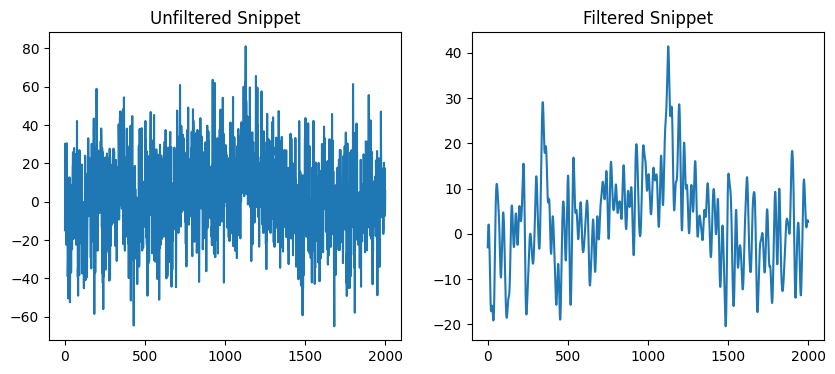

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

ax1.plot(X_sorted[0][10000:12000])
ax1.set_title("Unfiltered Snippet")

ax2.plot(filtered[10000:12000])
ax2.set_title("Filtered Snippet")

#Filtering did in fact work

In [26]:
def fit_gmm_threshold(feature_signal):
    """
    Fit 1 and 2 component GMMs, use BIC to select model (approximates MML).
    Returns threshold if 2 components win, None if 1 component wins (baseline only frame).
    """
    X_fit = feature_signal.reshape(-1, 1) # (n_samples, 1)
    
    gmm1 = GaussianMixture(n_components=1, covariance_type='full', random_state=42)
    gmm2 = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
    
    gmm1.fit(X_fit)
    gmm2.fit(X_fit)
    
    bic1 = gmm1.bic(X_fit)
    bic2 = gmm2.bic(X_fit)
    
    # If 1 component wins, frame is baseline only
    if bic1 <= bic2:
        return None
    
    # 2 components win — extract threshold
    means = gmm2.means_.flatten()
    order = np.argsort(means)
    means = means[order]
    stds = np.sqrt(gmm2.covariances_.flatten())[order]
    weights = gmm2.weights_[order]
    
    # Bayes optimal threshold = intersection between the two Gaussians
    x = np.linspace(means[0], means[1], 10000)
    pdf0 = weights[0] * norm.pdf(x, means[0], stds[0])
    pdf1 = weights[1] * norm.pdf(x, means[1], stds[1])
    threshold = x[np.argmin(np.abs(pdf0 - pdf1))]
    
    # Safety check — if threshold above max of feature signal, treat as baseline
    if threshold > feature_signal.max():
        print("Threshold is above signal max")
        return None
    
    return threshold


def detect_events(signal, fs, window=window_sample_count):

    whole_signal_std = np.std(signal)
    
    # Pad to multiple of frame_samples
    remainder = len(signal) % window
    if remainder != 0:
        pad_length = window - remainder
        signal_padded = np.pad(signal, (0, pad_length), mode='constant')
    else:
        signal_padded = signal.copy()
    
    n_frames = len(signal_padded) // window
    full_mask = np.zeros(len(signal_padded), dtype=bool)
   
    for i in range(n_frames):
        start = i * window
        end = start + window
        frame = signal_padded[start:end]
        
        # Compute feature signals
        env = hilbert_envelope(frame)
        ste = short_time_energy(frame, window)
        
        # Fit GMM independently to each feature
        thresh_ste = fit_gmm_threshold(ste)
        thresh_env = fit_gmm_threshold(env)
        
        # Generate masks — None threshold means all baseline
        mask_ste = (ste > thresh_ste) if thresh_ste is not None else np.zeros(window, dtype=bool)
        mask_env = (env > thresh_env) if thresh_env is not None else np.zeros(window, dtype=bool)
        
        full_mask[start:end] = mask_ste | mask_env
    
    # Trim back to original signal length
    full_mask = full_mask[:len(signal)]
    
    # Post-processing: SD filter
    # Remove detected events whose SD < SD of whole signal
    labeled_mask, n_events = label(full_mask)
    filtered_mask = np.zeros_like(full_mask)
    
    events_kept = 0

    for event_idx in range(1, n_events + 1):
        event_samples = signal[labeled_mask == event_idx]
        if np.std(event_samples) >= whole_signal_std:
            filtered_mask[labeled_mask == event_idx] = True
            events_kept += 1
    
    print(f"Candidate events before SD filter: {n_events}")
    print(f"Events after SD filter:            {events_kept}")
    
    return filtered_mask, signal

In [27]:
full_mask, signal_out = detect_events(filtered, fs=5000)

labeled_final, n_final = label(full_mask)
print(f"Final event count: {n_final}")

Candidate events before SD filter: 42116
Events after SD filter:            914
Final event count: 914


In [49]:
events = np.array(labeled_final != 0).nonzero()[0]

In [50]:
type(events)

numpy.ndarray

In [65]:
def filter_events(event_list, fs):
  prev = 0
  for event in event_list:
    if event - prev < fs/2: #If they are within half a second of each other its probably the same event
      print("deleted")
      idx = np.where(event_list == event)
      event_list = np.delete(event_list, idx)
    prev = event

  return event_list

In [ ]:
filtered_events = filter_events(events, fs)

deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted
deleted


In [ ]:
filtered_events[0]

np.int64(3390)

In [90]:
def plot_event(sig, idx):
  t = np.arange(int(idx-fs/10), int(idx+fs/10))*fs
  event = sig[int(idx-fs/10): int(idx+fs/10)]
  hilb = hilbert_envelope(event)
  ste = short_time_energy(event, window_sample_count)
  fig, axes = plt.subplots(3, 1, sharex='col')

  axes[0].plot(t, event)
  axes[0].set_title("Detected event")

  axes[1].plot(t, hilb)
  axes[1].set_title("Hilbert transform of event")

  axes[2].plot(t, ste)
  axes[2].set_title("Short Time Energy of event")


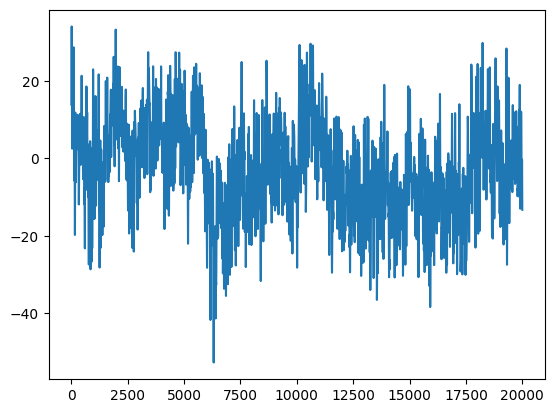

In [97]:
idx = filtered_events[10]
plt.plot(filtered[idx-10000: idx+10000])

In [52]:
import numpy as np
from scipy import signal as sps
from scipy.ndimage import label, binary_closing, standard_deviation


def bandpass(x, fs, lo, hi, order=4):
    sos = sps.butter(order, [lo, hi], btype='band', fs=fs, output='sos')
    return sps.sosfiltfilt(sos, x)


def estimate_band(burst_snippet, quiet_snippet, fs):
    """PSD ratio: where burst spectrum most exceeds baseline = your detection band."""
    f, p_burst = sps.welch(burst_snippet, fs=fs, nperseg=min(4096, len(burst_snippet)))
    _, p_quiet = sps.welch(quiet_snippet, fs=fs, nperseg=min(4096, len(quiet_snippet)))
    ratio = p_burst / (p_quiet + 1e-12)
    band = f[ratio > ratio.max() * 0.5]          # freqs with strong separation
    return float(band.min()), float(band.max()), f, ratio


def log_band_power(x, fs, lo, hi, win_ms=50):
    """Detection feature: log power in the burst band, sliding window."""
    xb = bandpass(x, fs, lo, hi)
    win = int(win_ms * fs / 1000)
    power = np.convolve(xb**2, np.ones(win) / win, mode='same')
    return np.log(power + 1e-12)                  # log -> ~Gaussian baseline


def detect_events(signal_raw, fs, quiet_stretch, lo=2, hi=50,
                  win_ms=50, k=4.0, min_dur_ms=20, merge_gap_ms=30):
    """
    quiet_stretch: 1D array you've eyeballed as event-free (used to set baseline).
    k: threshold in robust SDs above baseline median.
    """
    feat = log_band_power(signal_raw, fs, lo, hi, win_ms)

    # Baseline stats from YOUR labeled quiet data, in the same feature space
    quiet_feat = log_band_power(quiet_stretch, fs, lo, hi, win_ms)
    med = np.median(quiet_feat)
    mad = np.median(np.abs(quiet_feat - med))
    sigma = 1.4826 * mad                          # robust SD estimate
    threshold = med + k * sigma

    mask = feat > threshold

    # Merge events separated by small gaps, then drop too-short ones
    merge_gap = int(merge_gap_ms * fs / 1000)
    mask = binary_closing(mask, structure=np.ones(merge_gap))

    labeled, n = label(mask)
    min_dur = int(min_dur_ms * fs / 1000)
    out = np.zeros_like(mask)
    kept = 0
    if n > 0:
        sizes = np.bincount(labeled.ravel())[1:]  # samples per event
        keep = np.nonzero(sizes >= min_dur)[0] + 1
        out = np.isin(labeled, keep)
        kept = keep.size

    print(f"Candidate events: {n}  |  after duration filter: {kept}")
    return out, threshold

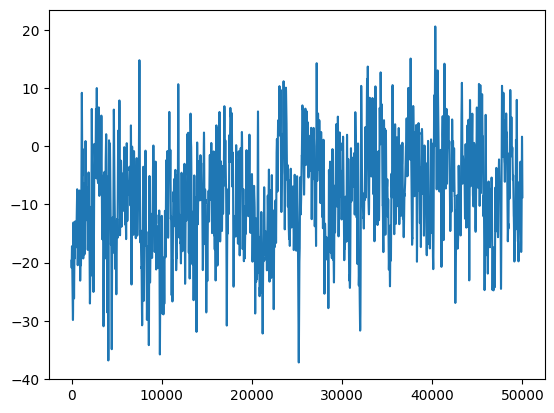

In [66]:
plt.plot(filtered[450000:500000])

In [77]:
# 1. Pick a quiet window and a burst window by eye (sample indices)
q0 = 450000
q1 = 500000
b0 = idx-4000
b1 = idx+4000
quiet = filtered[q0:q1]
burst = filtered[b0:b1]
# 2. Let the data tell you the band
lo, hi, f, ratio = estimate_band(burst, quiet, fs=5000)
print(f"Suggested band: {lo:.1f}-{hi:.1f} Hz")

# 3. Detect
mask, thr = detect_events(filtered, fs=5000, quiet_stretch=quiet,
                          lo=lo, hi=hi, k=4.0)

Suggested band: 0.0-7.3 Hz


ValueError: filter critical frequencies must be greater than 0

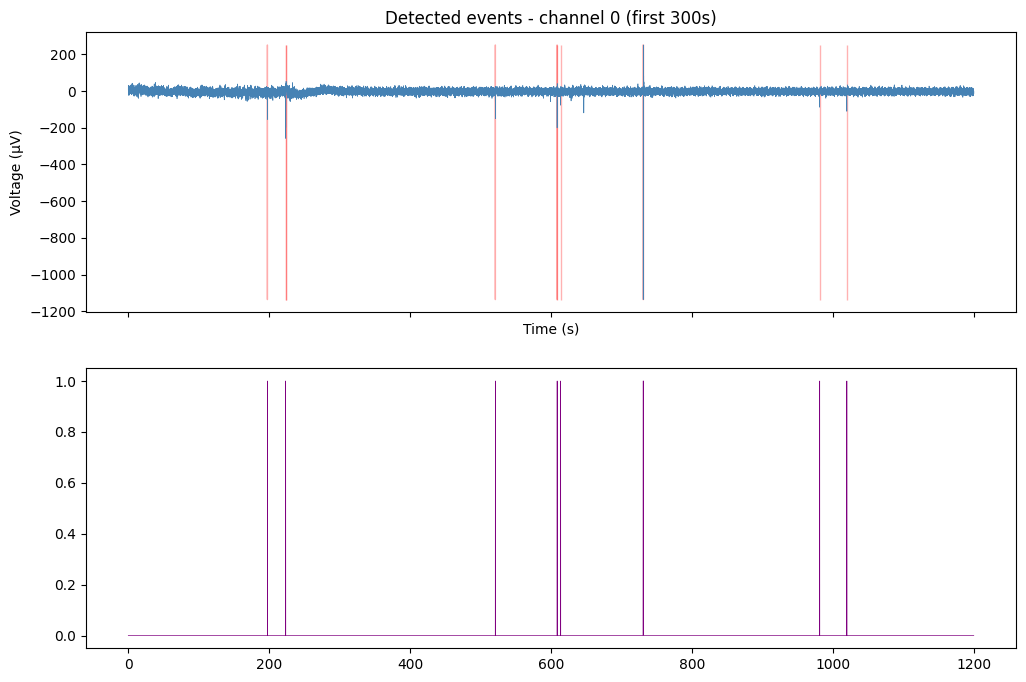

In [68]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(t, filtered, color='steelblue', linewidth=0.5)
ax1.fill_between(t, filtered.min(), filtered.max(),
                 where=mask, alpha=0.3, color='red', label='Detected')
ax1.set_title('Detected events - channel 0 (first 300s)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Voltage (µV)')

ax2.plot(t, mask.astype(int),
         linewidth=0.5, color='purple')

In [ ]:
idx = 0
flag = Fals

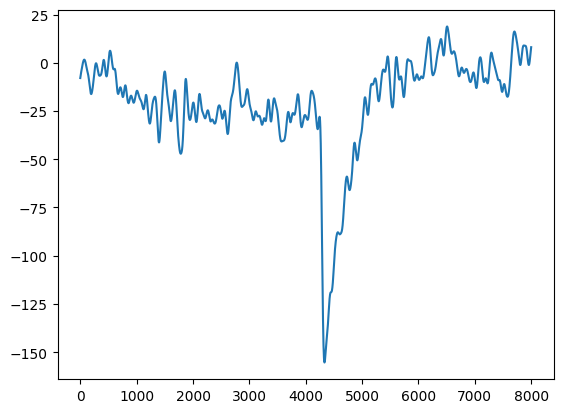

In [74]:
plt.plot(filtered[idx-4000:idx+4000])

## **Multi-thresholding algorithm (self-designed)**

### **Scrutinizing Params**

In [9]:
signal = bandpass_filter(X[0]) #Channel 47

In [10]:
signal.shape #type splih

(1199900,)

In [8]:
#Filtration band
BAND=(0.1, 200)

#Sampling frequency post-decimation (factor of 25)
FS=1000

#Fraction for threshold and event bound computation 
FRAC=0.1

#Filter b and a reused every single time, since the band and fs are fixed
B, A = sps.butter(3, list(BAND), btype="bandpass", fs=FS)

def mad_noise_std(x):
    return float(np.median(np.abs(x - np.median(x))) / 0.6745)


def bandpass_filter(data):
    return sps.filtfilt(B, A, data)


def refine_peaks(data, candidates, window_s=0.150):
    if len(candidates) == 0:
        return []

    half = int(window_s * FS)
    centered = data - np.median(data)
    refined = []

    for peak in candidates:
        lo = max(0, int(peak) - half)
        hi = min(len(data), int(peak) + half)

        chunk = centered[lo:hi]

        if len(chunk) == 0:
            continue

        local = int(np.argmin(chunk))

        refined.append(lo + local)

    return refined


def validate_event(
    signal,
    peak_idx,
    min_duration_s=0.08,
    max_slope_uv_per_sample=8,
    min_area=500,
    min_decay_s=0.05,
    max_overshoot_s=1,
    overshoot_frac=0.2,
):
    peak = signal[peak_idx]

    thresh = peak * FRAC

    # contiguous region below threshold
    left = peak_idx
    while left > 0 and signal[left] < thresh:
        left -= 1

    right = peak_idx
    while right < len(signal)-1 and signal[right] < thresh:
        right += 1

        # --- area check ---
    area = np.sum(np.abs(chunk))

    cap = min(len(signal), right + int(max_overshoot_s * FS))

    pos_region = signal[right:cap]
    pos_peak_local = int(np.argmax(pos_region))
    pos_peak = float(pos_region[pos_peak_local])

    if pos_peak >= abs(peak) * overshoot_frac:
        pos_peak_idx = right + pos_peak_local
        pos_thresh = pos_peak * FRAC
        pos_right = pos_peak_idx
        while pos_right < len(signal) - 1 and signal[pos_right] > pos_thresh:
            pos_right += 1
        pos_lobe = signal[right:pos_right]
        area += float(np.sum(pos_lobe[pos_lobe > 0]))
        right = pos_right
        

    if area < min_area:
        return False

    duration_s = (right - left) / FS

    # --- duration check ---
    if duration_s < min_duration_s:
        return False

    chunk = signal[left:right]

    # --- slope check ---
    if np.max(np.abs(np.diff(chunk))) > max_slope_uv_per_sample:
        return False

    # --- decay timing check ---
    if (right - peak_idx) / FS < min_decay_s:
        return False

    return True


def detect_events(
    data,
    height_k=5.0,
    prominence_k=4.0,
    min_distance_s=0.5,
    min_width_s=0.020,
    refine_window_s=0.150,
    min_duration_s=0.08,
    max_slope_uv_per_sample=8,
    min_area=500,
    min_decay_s=0.05,
):
    if data is None or len(data) == 0:
        return []

    # --- Detection signal ---
    detect_signal = bandpass_filter(data)

    noise_std = mad_noise_std(detect_signal)

    if noise_std == 0:
        return []

    target = -detect_signal

    # --- Thresholds ---
    h_thresh = height_k * noise_std

    p_thresh = prominence_k * noise_std

    # --- First-pass peak finding ---
    candidates, _ = sps.find_peaks(
        target,
        height=h_thresh,
        prominence=p_thresh,
        distance=max(1, int(min_distance_s * FS)),
        width=max(1, int(min_width_s * FS)),
    )

    # --- Peak refinement ---
    refined = refine_peaks(
        detect_signal,
        candidates,
        window_s=refine_window_s,
    )

    # --- Morphological validation ---
    refined = [
        idx
        for idx in refined
        if validate_event( 
            detect_signal,
            idx,
            min_duration_s=min_duration_s,
            max_slope_uv_per_sample=max_slope_uv_per_sample,
            min_area=min_area,
            min_decay_s=min_decay_s,
        )
    ]

    return refined

In [17]:
max_overshoot_s=1
overshoot_frac=0.2

def _robust_right_boundary(signal, start, thresh, min_consec=5):
    """Walk right until signal stays >= thresh for min_consec consecutive samples."""
    consec = 0
    i = start
    while i < len(signal) - 1:
        if signal[i] >= thresh:
            consec += 1
            if consec >= min_consec:
                return i - consec + 1
        else:
            consec = 0
        i += 1
    return len(signal) - 1


def event_snippet(sig, peak_idx):
    peak = sig[peak_idx]
    area = 0
    thresh = peak * FRAC

    # contiguous region below threshold
    left = peak_idx
    while left > 0 and signal[left] < thresh:
        left -= 1

    right = _robust_right_boundary(sig, peak_idx, thresh, 5)
    return sig[left:right]

In [11]:
biphasic_event_times = [57.043, 71.686, 80.537, 91.019, 126.186, 147.015, 168.649, 181.723, 185.646, 238.713, 239.333, 269.244, 345.888, 380.091, 396.071, 562.590]
monophasic_event_times = [10.058, 148.907, 151.767, 217.180, 255.175, 511.326, 651.059]
biphasic_event_indices = [int(t * FS) for t in biphasic_event_times]
monophasic_event_indices = [int(t * FS) for t in monophasic_event_times]
biphasic_event_traces = [event_snippet(signal, idx) for idx in biphasic_event_indices]
monophasic_event_traces = [event_snippet(signal, idx) for idx in monophasic_event_indices]

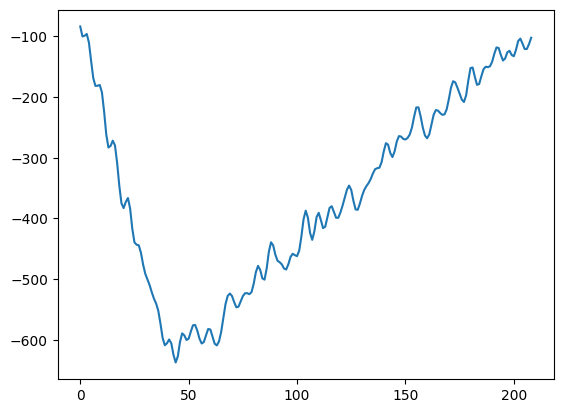

In [12]:
plt.plot(monophasic_event_traces[0])

In [13]:
#computing overshoot_frac manually
avg_min = []
avg_max = []

for snippet in biphasic_event_traces:
  mini = min(snippet)
  maxi = max(snippet)
  avg_min.append(mini)
  avg_max.append(maxi)

print(f"Median minimum value across all biphasic events: {np.median(avg_min)}")
print(f"Median maximum value across all biphasic events: {np.median(avg_max)}")
print(f"Median overshoot fraction: {abs(np.median(avg_max)) / abs(np.median(avg_min)):.2f}")
#There were some serious outliers here skewing this really hard, this is more reasonable. 

Median minimum value across all biphasic events: -520.1717026130751
Median maximum value across all biphasic events: 287.7948893119814
Median overshoot fraction: 0.55


## **Manual Parameter Tuning**

### **Universal params (for now...)**

In [14]:
min_duration_s=0.08
max_slope_uv_per_sample=8
min_area=500
min_decay_s=0.05
max_overshoot_s=1
overshoot_frac=0.2

### **Duration**

In [15]:
def computed_duration(sig, peak_idx):
  peak = sig[peak_idx]
  thresh = peak * FRAC

  # contiguous region below threshold
  left = peak_idx
  while left > 0 and signal[left] < thresh:
    left -= 1

  right = peak_idx
  while right < len(signal)-1 and signal[right] < thresh:
    right += 1

  return (right - left)*FS / 1000 #in ms I am pretty sure

In [16]:
biphasic_event_durations = [computed_duration(signal, idx) for idx in biphasic_event_indices]
monophasic_event_durations = [computed_duration(signal, idx) for idx in monophasic_event_indices]

### **Area**

In [17]:
def computed_area(sig, peak_idx):
    peak = sig[peak_idx]
    thresh = peak * FRAC

    # contiguous region below threshold
    left = peak_idx
    while left > 0 and signal[left] < thresh:
        left -= 1

    right = peak_idx
    while right < len(signal)-1 and signal[right] < thresh:
        right += 1

    event = signal[left:right]

    area = np.sum(np.abs(event))

    cap = min(len(signal), right + int(max_overshoot_s * FS))
    if cap > right:
        pos_region = signal[right:cap]
        pos_peak_local = int(np.argmax(pos_region))
        pos_peak = float(pos_region[pos_peak_local])

        if pos_peak >= abs(peak) * overshoot_frac:
            pos_peak_idx = right + pos_peak_local
            pos_thresh = pos_peak * FRAC
            pos_right = pos_peak_idx
            while pos_right < len(signal) - 1 and signal[pos_right] > pos_thresh:
                pos_right += 1
            pos_lobe = signal[right:pos_right]
            area += float(np.sum(pos_lobe[pos_lobe > 0]))

    return area

In [18]:
biphasic_event_areas = [computed_area(signal, idx) for idx in biphasic_event_indices]
monophasic_event_areas = [computed_area(signal, idx) for idx in monophasic_event_indices]

### **Slope**

In [19]:
def computed_slope(chunk):
  return np.max(np.abs(np.diff(chunk)))

In [20]:
biphasic_event_slopes = [computed_slope(chunk) for chunk in biphasic_event_traces]
monophasic_event_slopes = [computed_slope(chunk) for chunk in monophasic_event_traces]

### **Decay Time**

In [21]:
def computed_decay_time(sig, peak_idx):
  peak = sig[peak_idx]

  thresh = peak * FRAC

  right = peak_idx
  while right < len(signal)-1 and signal[right] < thresh:
    right += 1

  decay_time = (right - peak_idx) * 1000 / FS #in milliseconds
  
  return decay_time 

In [22]:
biphasic_event_decay_times = [computed_decay_time(signal, idx) for idx in biphasic_event_indices]
monophasic_event_decay_times = [computed_decay_time(signal, idx) for idx in monophasic_event_indices]

### **Visualizing Params**

In [23]:
all_durations = biphasic_event_durations + monophasic_event_durations

In [24]:
len(all_durations)

23

In [25]:
graph_X = np.arange(1, 24)

In [26]:
bed_std = np.std(all_durations)
bed_mu = np.mean(all_durations)
bed_u_thresh = bed_mu + 2.25 * bed_std
bed_l_thresh = bed_mu - 2.25 * bed_std

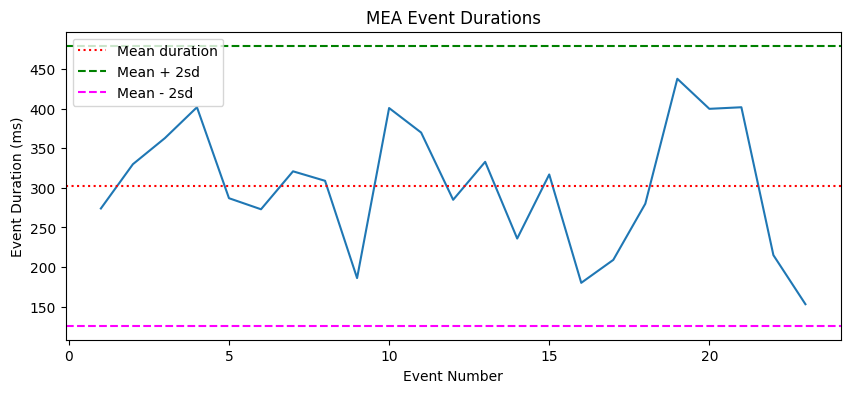

In [27]:
#Lets look at duration first
fig, ax = plt.subplots(1,1, figsize=(10,4))
ax.plot(graph_X, all_durations)
ax.set_title("MEA Event Durations")
ax.set_ylabel("Event Duration (ms)")
ax.set_xlabel("Event Number")
ax.axhline(bed_mu, c="red", ls=":", label="Mean duration")
ax.axhline(bed_u_thresh, c="g", ls="--", label="Mean + 2sd") #Maybe a good upper bound
ax.axhline(bed_l_thresh, c="#FF00FF", ls="--", label="Mean - 2sd") #Maybe a good lower bound
ax.legend(loc=2)

In [28]:
#Repeat for the other three thresholds
all_areas = biphasic_event_areas + monophasic_event_areas
aa_mu = np.mean(all_areas)
aa_std = np.std(all_areas)

aa_u_thresh = aa_mu + 3 * aa_std
aa_l_thresh = aa_mu - 1.25 * aa_std

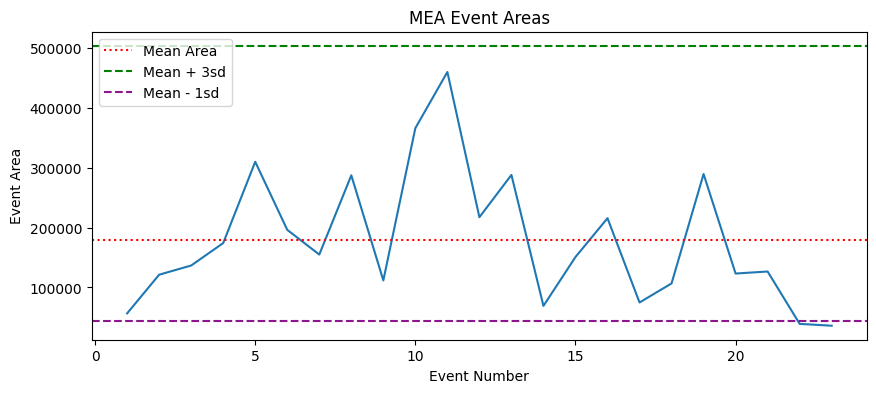

In [29]:
fig, ax = plt.subplots(1,1, figsize=(10,4))
ax.plot(graph_X, all_areas)
ax.set_title("MEA Event Areas")
ax.set_ylabel("Event Area")
ax.set_xlabel("Event Number")
ax.axhline(aa_mu, c="red", ls=":", label="Mean Area")
ax.axhline(aa_u_thresh, c="g", ls="--", label="Mean + 3sd") #Maybe a good upper bound
ax.axhline(aa_l_thresh, c="#8E1590", ls="--", label="Mean - 1sd") #Maybe a good lower bound
ax.legend(loc=2)

In [30]:
all_slopes = biphasic_event_slopes + monophasic_event_slopes
as_mu = np.mean(all_slopes)
as_std = np.std(all_slopes)
as_u_thresh = as_mu + 2.25 * as_std
as_l_thresh = as_mu - 1.75 * as_std

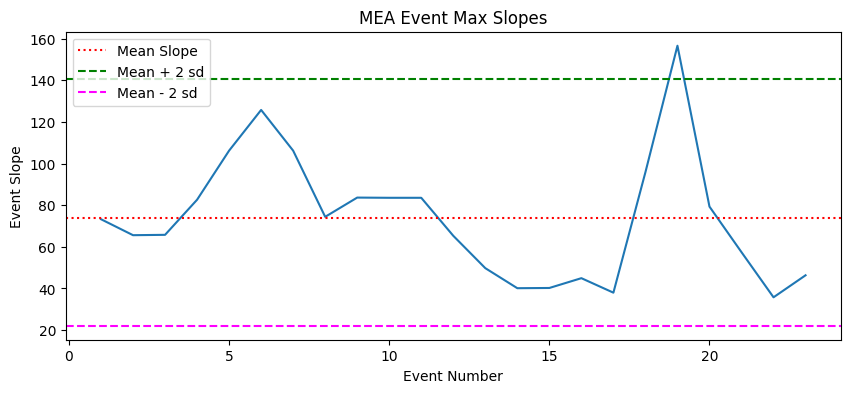

In [31]:
fig, ax = plt.subplots(1,1, figsize=(10,4))
ax.plot(graph_X, all_slopes)
ax.set_title("MEA Event Max Slopes")
ax.set_ylabel("Event Slope")
ax.set_xlabel("Event Number")
ax.axhline(as_mu, c="red", ls=":", label="Mean Slope")
ax.axhline(as_u_thresh, c="g", ls="--", label="Mean + 2 sd") #Maybe a good upper bound
ax.axhline(as_l_thresh, c="#FF00FF", ls="--", label="Mean - 2 sd") #Maybe a good lower bound
ax.legend(loc=2)

In [32]:
all_decays = biphasic_event_decay_times + monophasic_event_decay_times

ad_mu = np.mean(all_decays)
ad_sd = np.std(all_decays)

ad_u_thresh = ad_mu + 2.25 * ad_sd
ad_l_thresh = ad_mu - 2.25 * ad_sd

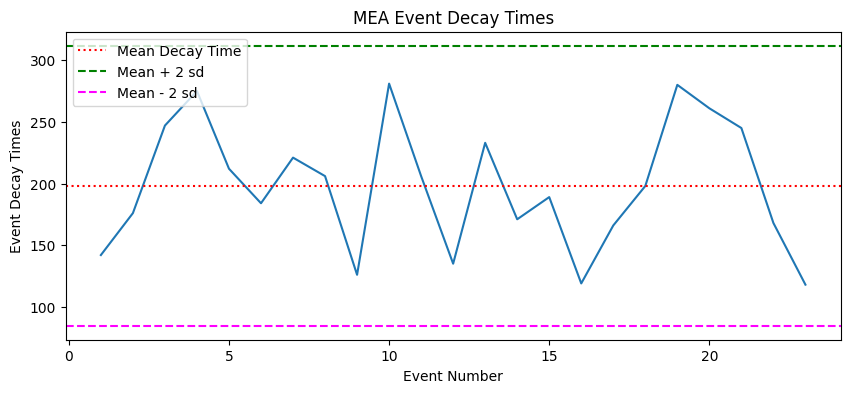

In [33]:
fig, ax = plt.subplots(1,1, figsize=(10,4))
ax.plot(graph_X, all_decays)
ax.set_title("MEA Event Decay Times")
ax.set_ylabel("Event Decay Times")
ax.set_xlabel("Event Number")
ax.axhline(ad_mu, c="red", ls=":", label="Mean Decay Time")
ax.axhline(ad_u_thresh, c="g", ls="--", label="Mean + 2 sd") #Maybe a good upper bound
ax.axhline(ad_l_thresh, c="#FF00FF", ls="--", label="Mean - 2 sd") #Maybe a good lower bound
ax.legend(loc=2)

In [ ]:
#Final thresholds

#SLOPE
slope_max = as_mu + 2.25 * as_std
slope_min = as_mu - 1.75 * as_std

#AREA
area_max = aa_mu + 3 * aa_std
area_min = aa_mu - 1.25 * aa_std

#DURATION
duration_max = bed_mu + 2.25 * bed_std
duration_min = bed_mu - 2.25 * bed_std

#DECAY
decay_max = ad_mu + 2.25 * ad_sd
decay_min = ad_mu - 2.25 * ad_sd

print(f"Slope thresholds established: must be between {slope_min:.2f} and {slope_max:.2f}")
print(f"Area thresholds established: must be between {area_min:.2f} and {area_max:.2f}")
print(f"Duration thresholds established: must be between {duration_min:.2f} and {duration_max:.2f}")
print(f"Decay thresholds established: must be between {decay_min:.2f} and {decay_max:.2f}")

Slope thresholds established: must be between -14.87 and 162.71
Area thresholds established: must be between -146221.66 and 503912.63
Duration thresholds established: must be between 66.77 and 538.80
Decay thresholds established: must be between 46.86 and 349.57


In [40]:
import sys
sys.path.insert(0, "src")
import mea_io, detection

data, fs = mea_io.read_and_decimate(file_name, 0)
events = detection.detect_events(data, debug=True)


[debug] noise_std=3.504  h_thresh=17.518  p_thresh=14.014
[debug] find_peaks candidates: 91
[debug] after refine_peaks: 91
  t=5.427s  FAIL  area 3199.7 < 43400.8
  t=10.059s  FAIL  area 7744.0 < 43400.8
  t=12.954s  FAIL  decay 50.0ms < 84.7ms
  t=28.837s  FAIL  duration 23.0ms < 125.8ms
  t=35.006s  FAIL  duration 58.0ms < 125.8ms
  t=57.043s  FAIL  area 5653.7 < 43400.8
  t=67.949s  FAIL  duration 78.0ms < 125.8ms
  t=71.686s  FAIL  area 12717.4 < 43400.8
  t=75.526s  FAIL  duration 6.0ms < 125.8ms
  t=80.607s  FAIL  area 12703.7 < 43400.8
  t=81.798s  FAIL  duration 6.0ms < 125.8ms
  t=83.178s  FAIL  duration 97.0ms < 125.8ms
  t=84.608s  FAIL  decay 12.0ms < 84.7ms
  t=85.910s  FAIL  duration 25.0ms < 125.8ms
  t=91.019s  FAIL  area 13500.0 < 43400.8
  t=104.896s  FAIL  duration 7.0ms < 125.8ms
  t=105.469s  FAIL  duration 10.0ms < 125.8ms
  t=109.276s  FAIL  duration 6.0ms < 125.8ms
  t=116.064s  FAIL  duration 30.0ms < 125.8ms
  t=120.724s  FAIL  duration 31.0ms < 125.8ms
  t=12

In [43]:
def plot_event(time):
  idx = int(time * FS / 1000)
  plt.plot(signal[idx - 2000: idx + 2000])
  plt.title(f"Event at {time} seconds")

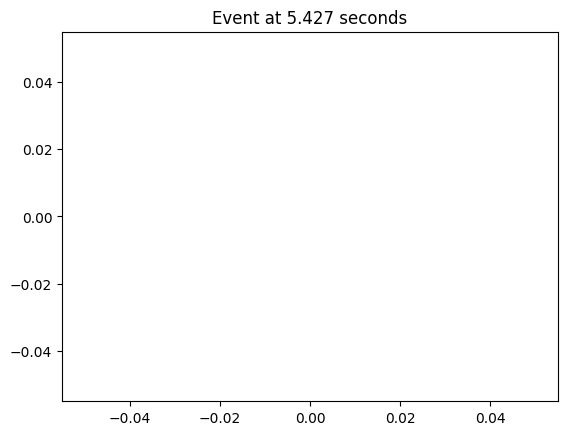

In [44]:
plot_event(5.427)

In [56]:
%load_ext autoreload
%autoreload 2
import importlib
importlib.reload(detection)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<module 'detection' from 'c:\\Users\\Armaa\\OneDrive\\Desktop\\Population Event Detection Project\\src\\detection.py'>

In [64]:
def _validate_event_debug(signal, peak_idx,
    min_duration_s=0.05, max_slope_uv_per_sample=140.51,
    min_area=43400.84, min_decay_s=0.0847,
    max_overshoot_s=1, overshoot_frac=0.2,
    boundary_consec=5,
):
    """Returns a string describing which check failed (or 'PASS')."""
    peak = signal[peak_idx]
    thresh = peak * FRAC

    left = peak_idx
    while left > 0 and signal[left] < thresh:
        left -= 1
    right = _robust_right_boundary(signal, peak_idx, thresh, min_consec=boundary_consec)

    duration_s = (right - left) / FS
    if duration_s < min_duration_s:
        return f"duration {duration_s*1000:.1f}ms < {min_duration_s*1000:.1f}ms"

    chunk = signal[left:right]
    slope = np.max(np.abs(np.diff(chunk)))
    if slope > max_slope_uv_per_sample:
        return f"slope {slope:.2f} > {max_slope_uv_per_sample:.2f}"

    decay_time = (right - peak_idx) / FS
    if decay_time < min_decay_s:
        return f"decay {decay_time*1000:.1f}ms < {min_decay_s*1000:.1f}ms"

    area = np.sum(np.abs(chunk))
    cap = min(len(signal), right + int(max_overshoot_s * FS))
    if cap > right:
        pos_region = signal[right:cap]
        pos_peak_local = int(np.argmax(pos_region))
        pos_peak = float(pos_region[pos_peak_local])
        if pos_peak >= abs(peak) * overshoot_frac:
            pos_peak_idx = right + pos_peak_local
            pos_thresh = pos_peak * FRAC
            pos_right = pos_peak_idx
            while pos_right < len(signal) - 1 and signal[pos_right] > pos_thresh:
                pos_right += 1
            area += float(np.sum(signal[right:pos_right][signal[right:pos_right] > 0]))

    if area < min_area:
        return f"area {area:.1f} < {min_area:.1f}"

    return "PASS"

In [65]:
def plot_rejected_events(data, window_ms=600, ncols=5, max_events=60,
                         height_k=5.0, prominence_k=4.0,
                         min_distance_s=0.5, min_width_s=0.020):
    """
    Plot candidates that survived find_peaks but were rejected by validate_event.
    Colors: blue=area, red=duration, orange=slope, purple=decay
    """
    from scipy import signal as sps
    from collections import Counter
    import matplotlib.pyplot as plt

    FS = detection.FS
    filtered = detection.bandpass_filter(data)
    noise_std = detection.mad_noise_std(filtered)

    candidates, _ = sps.find_peaks(
        -filtered,
        height=height_k * noise_std,
        prominence=prominence_k * noise_std,
        distance=max(1, int(min_distance_s * FS)),
        width=max(1, int(min_width_s * FS)),
    )
    refined = detection.refine_peaks(filtered, list(candidates))

    rejected, passed = [], 0
    for idx in refined:
        reason = _validate_event_debug(filtered, idx)
        if reason == "PASS":
            passed += 1
        else:
            rejected.append((idx, reason))

    print(f"find_peaks: {len(candidates)}  →  after refine: {len(refined)}  →  passed validate: {passed}  →  rejected: {len(rejected)}")
    cats = Counter(r.split()[0] for _, r in rejected)
    for cat, n in sorted(cats.items(), key=lambda x: -x[1]):
        print(f"  {cat}: {n}")

    if not rejected:
        print("Nothing rejected — all candidates passed.")
        return

    to_plot = rejected[:max_events]
    if len(rejected) > max_events:
        print(f"  (showing first {max_events} of {len(rejected)})")

    half  = int(window_ms / 1000 * FS)
    nrows = (len(to_plot) + ncols - 1) // ncols
    colors = {"duration": "red", "slope": "darkorange", "decay": "purple", "area": "royalblue"}

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 2.2))
    axes = np.array(axes).flatten()

    for ax, (idx, reason) in zip(axes, to_plot):
        start = max(0, idx - half)
        end   = min(len(filtered), idx + half)
        t     = (np.arange(start, end) - idx) / FS * 1000
        cat   = reason.split()[0]
        ax.plot(t, filtered[start:end], linewidth=0.7, color="steelblue")
        ax.axvline(0, color="red", alpha=0.4, linewidth=0.8, ls="--")
        ax.set_title(f"t={idx/FS:.1f}s\n{reason}", fontsize=7,
                     color=colors.get(cat, "black"))
        ax.tick_params(labelsize=6)

    for ax in axes[len(to_plot):]:
        ax.set_visible(False)

    fig.suptitle(f"Rejected candidates — {len(rejected)} total | {passed} passed", fontsize=11)
    plt.tight_layout()
    plt.show()


In [67]:
def _robust_right_boundary(signal, start, thresh, min_consec=5):
    """
    Walk right from start until the signal stays >= thresh for min_consec
    consecutive samples. Returns the index where that run begins.
    Prevents a single noisy sample from terminating the boundary walk early.
    """
    consec = 0
    i = start
    while i < len(signal) - 1:
        if signal[i] >= thresh:
            consec += 1
            if consec >= min_consec:
                return i - consec + 1
        else:
            consec = 0
        i += 1
    return len(signal) - 1

find_peaks: 91  →  after refine: 91  →  passed validate: 51  →  rejected: 40
  area: 18
  decay: 12
  duration: 7
  slope: 3


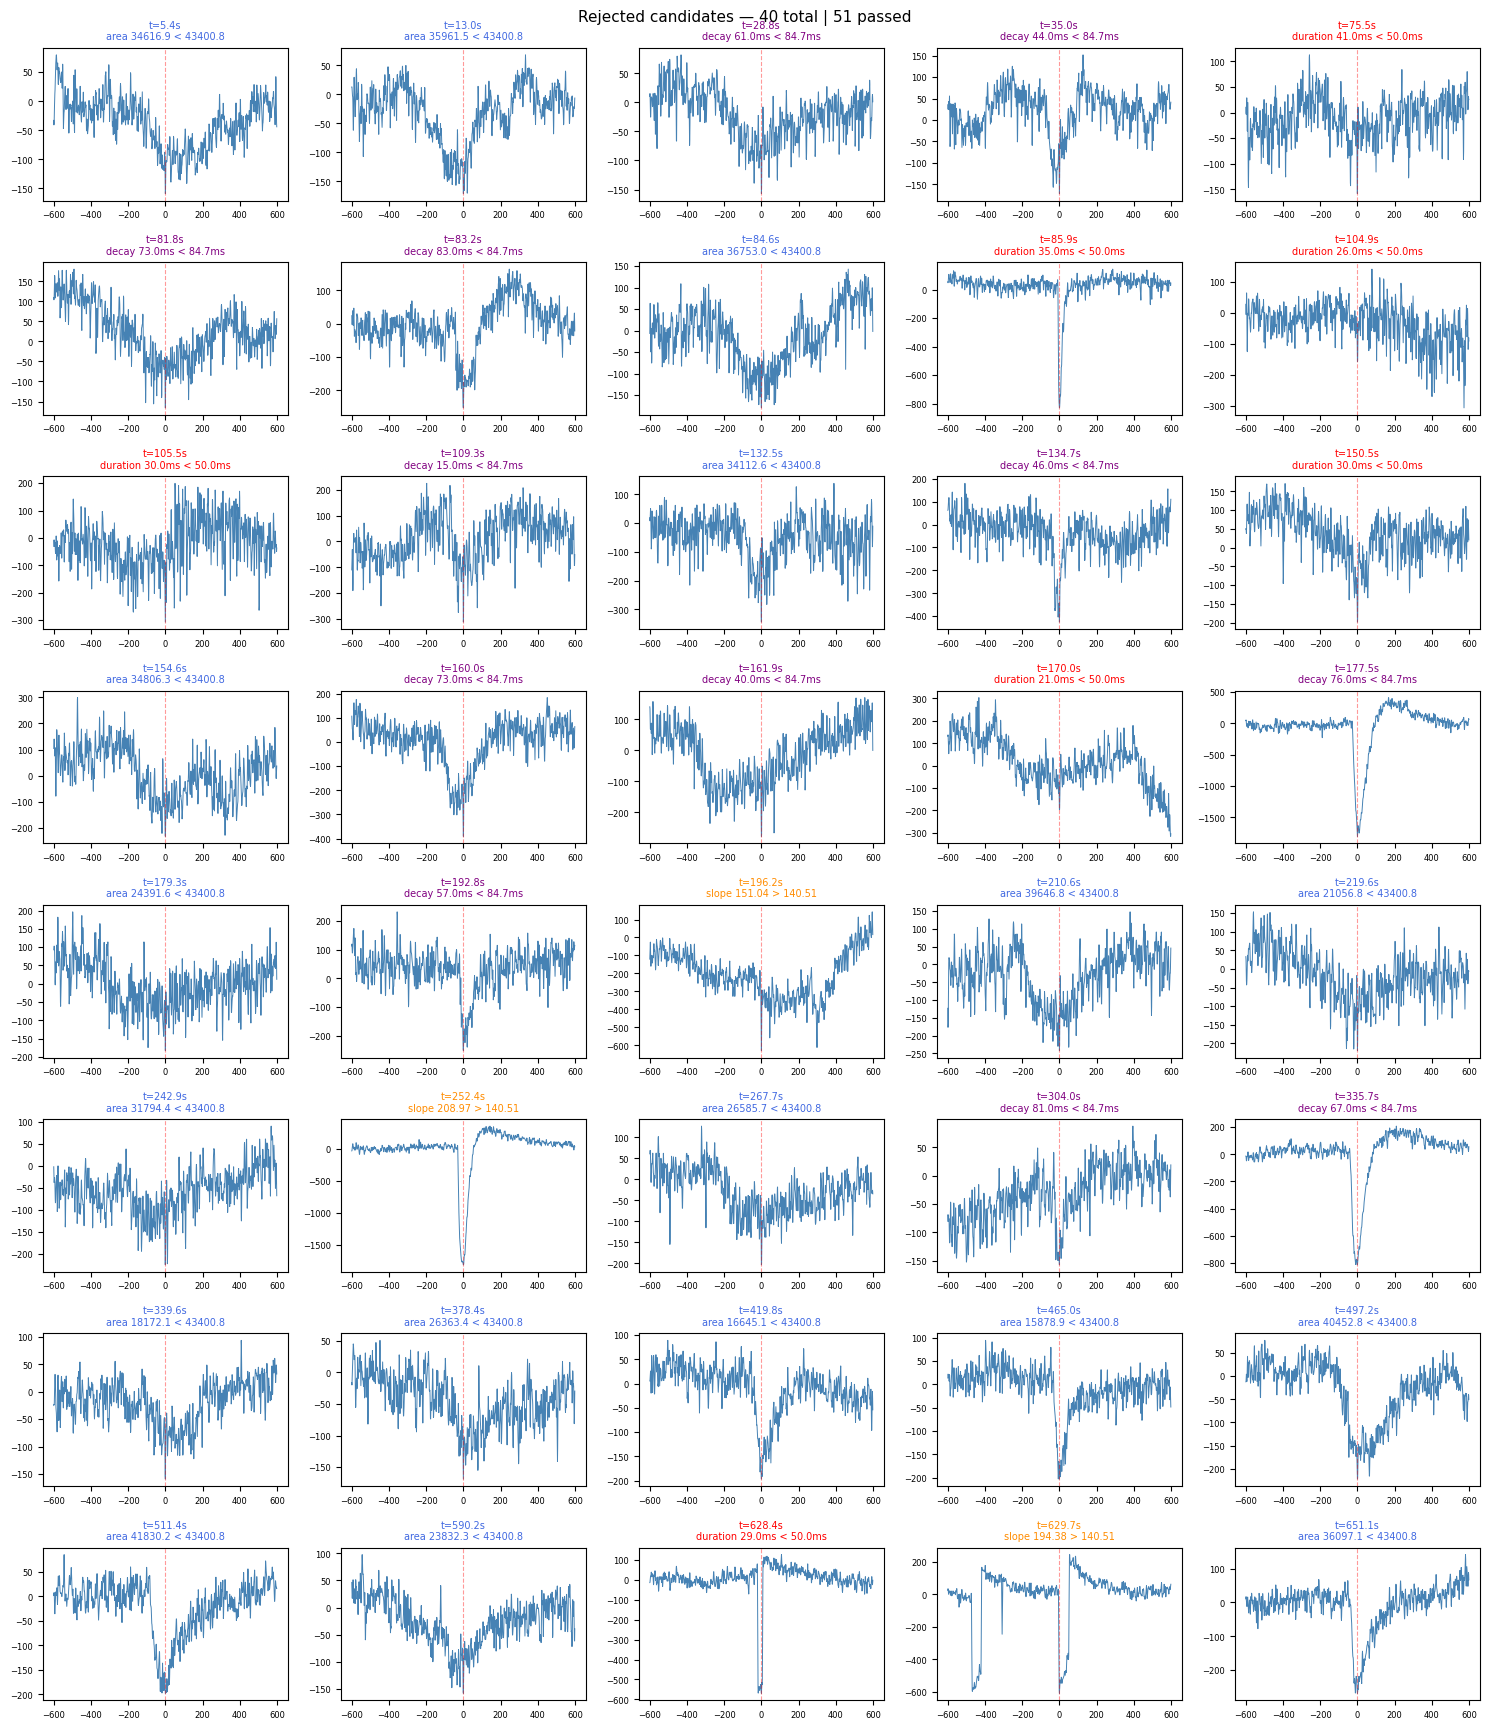

In [68]:
plot_rejected_events(X[0])

## **ML Event Classifier — Labeling and Training**

In [69]:
import sys, csv, os
sys.path.insert(0, "src")
import importlib
import numpy as np
import matplotlib.pyplot as plt
import mea_io, detection
importlib.reload(detection)
from scipy import signal as sps

LABEL_CSV = "labeled_candidates.csv"
FEATURE_KEYS = ["amplitude_uv", "duration_s", "rise_time_s", "decay_time_s",
                "slope_uv_per_ms", "area_uv_ms", "half_width_s"]

def get_candidates(ch_idx, height_k=5.0, prominence_k=4.0,
                   min_distance_s=0.5, min_width_s=0.020):
    """Return (filtered_signal, refined_peak_indices) for a channel."""
    data, _ = mea_io.read_and_decimate(file_name, ch_idx)
    filtered = detection.bandpass_filter(data)
    noise_std = detection.mad_noise_std(filtered)
    candidates, _ = sps.find_peaks(
        -filtered,
        height=height_k * noise_std,
        prominence=prominence_k * noise_std,
        distance=max(1, int(min_distance_s * detection.FS)),
        width=max(1, int(min_width_s * detection.FS)),
    )
    refined = detection.refine_peaks(filtered, list(candidates))
    print(f"Channel {ch_idx}: {len(candidates)} from find_peaks → {len(refined)} after refine")
    return filtered, refined

In [ ]:
# ── LABELING LOOP ──────────────────────────────────────────────────────────────
# Change CH_IDX to label a different channel. Run this cell multiple times
# across different channels — all labels append to the same CSV.
# Controls: y = event,  n = not an event,  q = quit and save progress
# ──────────────────────────────────────────────────────────────────────────────

CH_IDX = 0
WINDOW_MS = 600

filtered, refined = get_candidates(CH_IDX)

# Load already-labeled entries so we can skip them on resume
existing = set()
if os.path.exists(LABEL_CSV):
    with open(LABEL_CSV, newline="") as f:
        for row in csv.DictReader(f):
            existing.add((int(row["ch_idx"]), int(row["sample_idx"])))
    print(f"Resuming — {len(existing)} candidates already labeled across all channels")

fieldnames = ["ch_idx", "sample_idx", "time_s", "label"] + FEATURE_KEYS
write_header = not os.path.exists(LABEL_CSV) or os.path.getsize(LABEL_CSV) == 0

half = int(WINDOW_MS / 2 / 1000 * detection.FS)
labeled_this_run = 0

with open(LABEL_CSV, "a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    if write_header:
        writer.writeheader()

    for idx in refined:
        if (CH_IDX, idx) in existing:
            continue

        feats = detection.compute_features(filtered, idx)
        start = max(0, idx - half)
        end   = min(len(filtered), idx + half)
        t_ms  = (np.arange(start, end) - idx) / detection.FS * 1000

        fig, ax = plt.subplots(figsize=(10, 3))
        ax.plot(t_ms, filtered[start:end], linewidth=0.8, color="steelblue")
        ax.axvline(0, color="red", alpha=0.5, ls="--")
        ax.set_title(
            f"ch={CH_IDX}  t={idx/detection.FS:.3f}s  |  "
            f"amp={feats['amplitude_uv']:.1f}µV  "
            f"dur={feats['duration_s']*1000:.0f}ms  "
            f"area={feats['area_uv_ms']:.0f}  "
            f"half_w={feats['half_width_s']*1000:.0f}ms",
            fontsize=9
        )
        ax.set_xlabel("Time offset (ms)")
        ax.set_ylabel("µV")
        plt.tight_layout()
        plt.show()

        answer = input("Label — y (event) / n (not event) / q (quit): ").strip().lower()
        plt.close()

        if answer == "q":
            print(f"Stopped. Labeled {labeled_this_run} this run. Re-run cell to continue.")
            break
        elif answer not in ("y", "n"):
            print(f"  Skipping unrecognised input '{answer}'")
            continue

        row = {
            "ch_idx": CH_IDX, "sample_idx": idx,
            "time_s": round(idx / detection.FS, 4),
            "label": 1 if answer == "y" else 0,
        }
        row.update({k: round(feats[k], 6) for k in FEATURE_KEYS})
        writer.writerow(row)
        existing.add((CH_IDX, idx))
        labeled_this_run += 1
    else:
        print(f"All candidates on channel {CH_IDX} labeled ({labeled_this_run} this run).")

In [ ]:
# ── MODEL TRAINING ─────────────────────────────────────────────────────────────
# Run after labeling at least 2–3 channels worth of candidates.
# Saves model to src/event_classifier.joblib — detection.py picks it up from there.
# ──────────────────────────────────────────────────────────────────────────────

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib

df = pd.read_csv(LABEL_CSV)
n_events    = df["label"].sum()
n_nonevents = (df["label"] == 0).sum()
print(f"Labeled samples: {len(df)}  |  events: {n_events}  |  non-events: {n_nonevents}")

if n_events < 5 or n_nonevents < 5:
    print("Need at least 5 of each class before training — label more candidates first.")
else:
    X_train = df[FEATURE_KEYS].values
    y_train = df["label"].values

    clf = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )

    cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring="f1")
    print(f"5-fold CV F1: {scores.mean():.3f} ± {scores.std():.3f}")

    clf.fit(X_train, y_train)
    joblib.dump(clf, "src/event_classifier.joblib")
    print("Model saved → src/event_classifier.joblib")

    importances = sorted(zip(FEATURE_KEYS, clf.feature_importances_), key=lambda x: -x[1])
    print("\nFeature importances:")
    for feat, imp in importances:
        bar = "█" * int(imp * 40)
        print(f"  {feat:<20} {imp:.3f}  {bar}")

## **Tuning PSD args**

In [18]:
time = 126.186
idx = int(time * FS)
chunk = event_snippet(signal, idx)

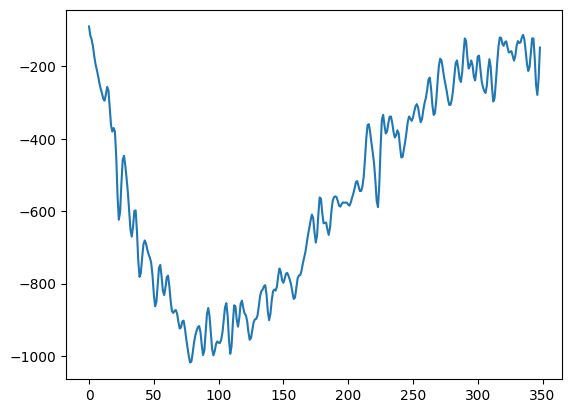

In [19]:
plt.plot(chunk)

In [ ]:
f, Pxx = sps.welch(x=chunk, fs=FS, window="ham", nfft=256, nperseg=5, noverlap=10)